In [46]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

from lmfit import Model, models

In [47]:
a = 10.6407982
b = 9.17514783
noz_ID = [32,32,32,64,64,64]

normalised_x = [
    (10 / (4.5 * noz * 10**-4)) * (a + b)
    for noz in noz_ID
]

print(normalised_x)

[13761.073631944442, 13761.073631944442, 13761.073631944442, 6880.536815972221, 6880.536815972221, 6880.536815972221]


In [48]:
diam = [179.76864624, 184.3699646, 177.406326294, 246.732009888, 254.487854004, 491.828399658]
outlier_index = 5
diam_for_mean = [d for i, d in enumerate(diam) if i != outlier_index]
a_diam = [d / (1.91 * noz) for d, noz in zip(diam, noz_ID)]


In [49]:
rel_err = 0.01 
err_noz_ID = [rel_err * noz for noz in noz_ID]
print(err_noz_ID)

# measured error in D[4][3]
err_mean_diam = [19.3167552948, 17.9351501465, 19.3943424225, 31.3087768555, 34.9372062683, 83.3335037231]
a_err_mean_diam = [
    e / (1.91 * noz)
    for e, noz in zip(err_mean_diam, noz_ID)
]
print(a_err_mean_diam)

[0.32, 0.32, 0.32, 0.64, 0.64, 0.64]
[0.3160463889856021, 0.29344159271106024, 0.31731581188645286, 0.25612546511371076, 0.28580829735193064, 0.6817204165829516]


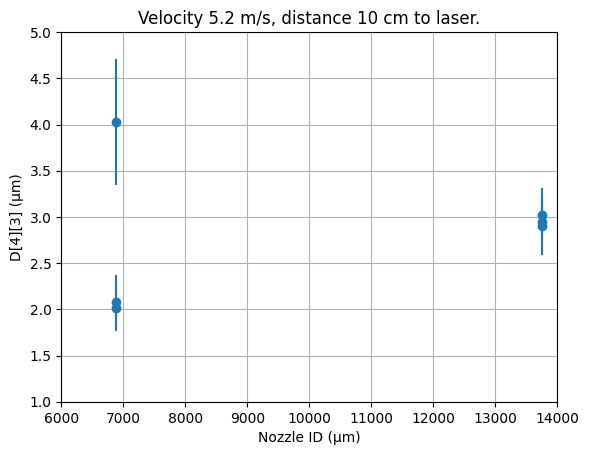

In [50]:
plt.figure()

plt.errorbar(normalised_x, a_diam, xerr=err_noz_ID, yerr=a_err_mean_diam, fmt='o')

plt.title(r"Velocity 5.2 m/s, distance 10 cm to laser.")
plt.xlabel(r"Nozzle ID (μm)")
plt.ylabel(r"D[4][3] (μm)")

plt.xlim(6000,14000)
plt.ylim(1,5)

plt.grid(True)
plt.show()

## fit

In [53]:
def linear_model(x, m, c):
    return m * x + c

fit_model = models.Model(linear_model)

mask = np.arange(len(diam)) != outlier_index

x_fit = np.array(normalised_x)[mask]
y_fit_data = np.array(a_diam)[mask]
weights = 1 / np.array(a_err_mean_diam)[mask]

fit_result = fit_model.fit(
    y_fit_data,
    x=x_fit,
    weights=weights,
    m=1,
    c=1
)

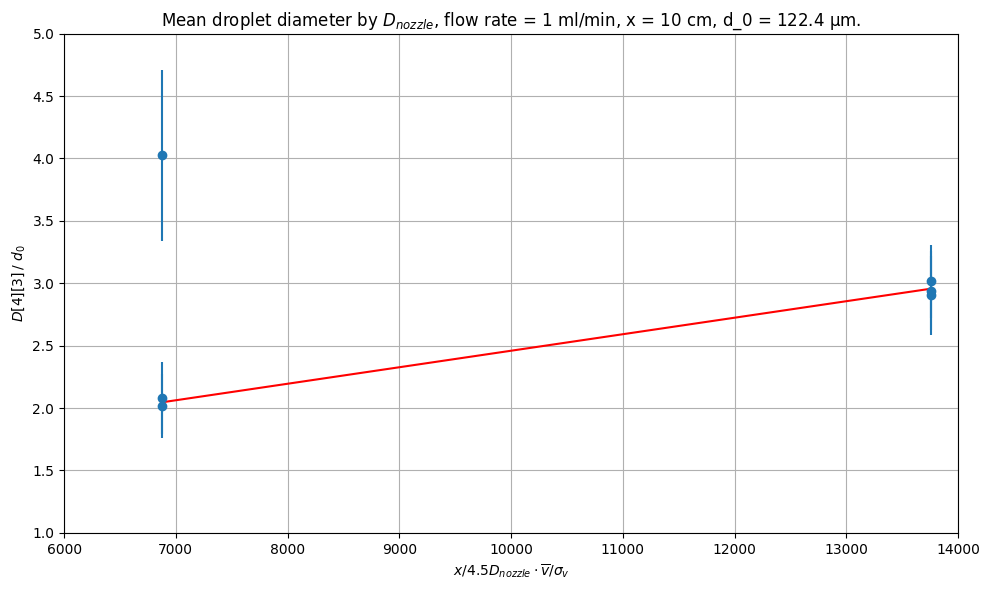

In [54]:
x = np.array(normalised_x)

idx = np.argsort(x)
x_sorted = x[idx]

y_sorted_fit = fit_result.eval(x=x_sorted)

plt.figure(figsize=(10,6))

plt.errorbar(normalised_x, a_diam,
             xerr=err_noz_ID,
             yerr=a_err_mean_diam,
             fmt='o')

plt.plot(x_sorted, y_sorted_fit, 'r-')

plt.title(r"Mean droplet diameter by $D_{nozzle}$, flow rate = 1 ml/min, x = 10 cm, d_0 = 122.4 μm.")
plt.xlabel(r"$ x / 4.5D_{nozzle} \cdot \overline{v} / \sigma_v$")
plt.ylabel(r"$D[4][3]\,/$ $d_0$")

plt.xlim(6000,14000)
plt.ylim(1,5)
plt.grid(True)
plt.tight_layout()

plt.show()

In [55]:
print(fit_result.fit_report())

[[Model]]
    Model(linear_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 5
    # variables        = 2
    chi-square         = 0.10036564
    reduced chi-square = 0.03345521
    Akaike info crit   = -15.5418663
    Bayesian info crit = -16.3229905
    R-squared          = 0.99110801
[[Variables]]
    m:  1.3227e-04 +/- 6.9357e-06 (5.24%) (init = 1)
    c:  1.13658148 +/- 0.07699937 (6.77%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(m, c) = -0.9510
